# Name:Ritika lund
# CMS-ID:023-24-0262
# Section:H
# Github:https://github.com/Ritika-Lund/Machine-learning-Lab.git
# Kaggle:https://www.kaggle.com/ritikalund
# Dataset:Telco churn dataset
# Dataset source:https://www.kaggle.com/datasets/vedatgul/telco-churn-dataset

# Part 1:  Decision Tree Baseline Review 

# Task 1

In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# Load cleaned dataset
df = pd.read_csv("clean_churn.csv")

print("Original shape:", df.shape)

# Check data
display(df.head())
print(df.columns)
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)
# Separate target
y = df["Churn"].map({"No": 0, "Yes": 1})

# Separate features
X = df.drop(columns=["Churn"])

print("X shape before encoding:", X.shape)
print("y shape:", y.shape)
# Find categorical columns
categorical_cols = X.select_dtypes(include=["object", "str"]).columns

# One-hot encoding
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    dtype=int
)

print("X shape after encoding:", X.shape)
print("Missing values:", X.isnull().sum().sum())
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Original shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')
Shape after removing duplicates: (7021, 20)
X shape before encoding: (7021, 19)
y shape: (7021,)
X shape after encoding: (7021, 45)
Missing values: 0
X_train: (5616, 45)
X_test: (1405, 45)
y_train: (5616,)
y_test: (1405,)


# task 1 interpretation
The cleaned Telco Churn dataset was loaded and preprocessed using the same procedure as Lab 3. Categorical variables were converted into numerical features using one-hot encoding, resulting in 45 features. The dataset was divided into 80% training and 20% testing data using random_state=42 and stratified sampling to maintain the original class distribution.

# Task 2

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)


dt_pred = dt_model.predict(X_test)

# Metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Results")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-score :", dt_f1)

Decision Tree Results
Accuracy : 0.7943060498220641
Precision: 0.6202898550724638
Recall   : 0.5752688172043011
F1-score : 0.596931659693166


# task 2 interpretation
The Decision Tree achieved approximately 79.4% accuracy and an F1-score of 59.7%. Although its overall accuracy is reasonable, its recall indicates that the model misses a considerable portion of customers who actually churn. Therefore, additional models should be evaluated to determine whether churn prediction can be improved.

# Part 2: Random Forest 

# Task 3

In [32]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


# Task 3 interpretation
A Random Forest was trained using 200 decision trees. The model combines predictions from multiple trees rather than relying on a single tree, which can help reduce overfitting and improve generalization to unseen data.

# Task 4
Random Forest combines multiple decision trees and averages their predictions, which reduces the variance of an individual tree. Because the trees are trained with different samples and feature subsets, the ensemble is generally less sensitive to the overfitting of any single tree and can therefore generalize better to unseen data.

# Part 3: Evaluation & Comparison

# Task 5

In [33]:
from sklearn.metrics import confusion_matrix

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)

print("\nConfusion Matrix:")
print(rf_cm)

Random Forest Results
---------------------
Accuracy : 0.7722419928825622
Precision: 0.5921985815602837
Recall   : 0.4489247311827957
F1-score : 0.5107033639143731

Confusion Matrix:
[[918 115]
 [205 167]]


# Task 5 interpretation
The Random Forest achieved an accuracy of 77.22%, precision of 59.22%, recall of 44.89%, and F1-score of 51.07%. The confusion matrix shows that the model correctly classified 918 non-churn customers and 167 churn customers. However, it incorrectly classified 205 actual churn customers as non-churn. Therefore, although the model achieves reasonable overall accuracy, its relatively low recall indicates that it misses a substantial number of customers who are likely to churn.

# Task 6

In [34]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall
    ],
    "F1-score": [
        dt_f1,
        rf_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.794306,0.620290,0.575269,0.596932
1,Random Forest,0.772242,0.592199,0.448925,0.510703


# Task 6 interpretation
The comparison table shows the performance difference between the single Decision Tree and the Random Forest across four evaluation metrics. The comparison is not based on accuracy alone, allowing us to assess both the model's overall correctness and its ability to identify churn cases.

# Task 7
Based on the evaluation results, the Decision Tree performs better overall. Its F1-score is 59.6%, compared with 51% for the other model, representing an improvement of approximately 8.6 percentage points. Since the dataset is imbalanced, F1-score and recall are more informative than accuracy alone because they provide better insight into the model's ability to identify churn customers.

# Part 4: Cross-Validation

# Task 8

In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Decision Tree CV
dt_cv_scores = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

# Random Forest CV
rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Decision Tree CV F1 scores:")
print(dt_cv_scores)

print("\nRandom Forest CV F1 scores:")
print(rf_cv_scores)

print("\nDecision Tree Mean F1:", dt_cv_scores.mean())
print("Decision Tree Std:", dt_cv_scores.std())

print("\nRandom Forest Mean F1:", rf_cv_scores.mean())
print("Random Forest Std:", rf_cv_scores.std())

Decision Tree CV F1 scores:
[0.57794677 0.54545455 0.56893543 0.54653465 0.52125693]

Random Forest CV F1 scores:
[0.55893536 0.54863813 0.52671756 0.59090909 0.54579439]

Decision Tree Mean F1: 0.5520256652326065
Decision Tree Std: 0.019889139893416584

Random Forest Mean F1: 0.5541989068393627
Random Forest Std: 0.021103811333800026


# task 8 interpretation
Five-fold cross-validation was used to evaluate model stability using F1-score. The mean CV score represents the average performance across the five folds, while the standard deviation indicates how much the performance varies between folds. A higher mean F1 with a relatively smaller standard deviation indicates stronger and more stable performance.

# Task 9

In [36]:
cv_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Test F1": [dt_f1, rf_f1],
    "CV Mean F1": [
        dt_cv_scores.mean(),
        rf_cv_scores.mean()
    ],
    "CV Std": [
        dt_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

cv_comparison

,Model,Test F1,CV Mean F1,CV Std
0,Decision Tree,0.596932,0.552026,0.019889
1,Random Forest,0.510703,0.554199,0.021104


# Task 9 interpretation 
The single train/test split showed that the Decision Tree achieved a higher F1-score (0.5969) than the Random Forest (0.5107). However, five-fold cross-validation produced very similar mean F1-scores, with Random Forest achieving 0.5542 compared with 0.5520 for the Decision Tree. The difference between the cross-validation scores is very small (0.0022), indicating that neither model has a clear advantage based on cross-validation alone. Therefore, the single test split and cross-validation provide slightly different conclusions, so further evaluation and hyperparameter tuning are required before selecting the final model.

# Part 5: Hyperparameter Tuning

# Task 10

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Hyperparameter values to test
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}


rf_for_tuning = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Train and search for the best combination
grid_search.fit(X_train, y_train)

print("Grid search completed.")
print("Number of parameter combinations tested:",end='')
print(len(grid_search.cv_results_["params"]))

Grid search completed.
Number of parameter combinations tested:8


# Task 10 interpretation
GridSearchCV evaluated 8 different Random Forest hyperparameter combinations using 5-fold cross-validation. The tuning process used F1-score as the evaluation metric because the dataset is imbalanced. The test set was kept separate from the tuning process to provide an unbiased evaluation later.

# Task 11

In [38]:
print("Best Hyperparameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(grid_search.best_score_)

results = pd.DataFrame(grid_search.cv_results_)

results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split",
        "mean_test_score",
        "std_test_score"
    ]
].sort_values(
    by="mean_test_score",
    ascending=False
)

Best Hyperparameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation F1-score:
0.5777530539514006


,param_n_estimators,param_max_depth,param_min_samples_split,mean_test_score,std_test_score
7,200,10,5,0.577753,0.017842
6,100,10,5,0.577437,0.016680
5,200,10,2,0.574344,0.026570
4,100,10,2,0.570954,0.020311
3,200,None,5,0.562475,0.025583
2,100,None,5,0.555279,0.019885
0,100,None,2,0.533926,0.025288
1,200,None,2,0.531682,0.022624


# Task 11 interpretation
GridSearchCV identified n_estimators=200, max_depth=10, and min_samples_split=5 as the best hyperparameter combination. This configuration achieved a mean cross-validation F1-score of 0.5778, which was the highest among the eight tested combinations. Compared with the default Random Forest CV F1-score of 0.5542, the tuned model improved the mean F1-score by approximately 2.36 percentage points. However, the final model must still be evaluated on the held-out test set before determining whether tuning actually improves generalization.

# Task 12

In [39]:
tuned_rf = grid_search.best_estimator_
tuned_rf_pred = tuned_rf.predict(X_test)
tuned_accuracy = accuracy_score(y_test, tuned_rf_pred)
tuned_precision = precision_score(y_test, tuned_rf_pred)
tuned_recall = recall_score(y_test, tuned_rf_pred)
tuned_f1 = f1_score(y_test, tuned_rf_pred)
print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1-score :", tuned_f1)
tuned_cm = confusion_matrix(y_test, tuned_rf_pred)
print("Confusion Matrix:")
print(tuned_cm)

Tuned Random Forest Results
---------------------------
Accuracy : 0.798576512455516
Precision: 0.656140350877193
Recall   : 0.5026881720430108
F1-score : 0.5692541856925418
Confusion Matrix:
[[935  98]
 [185 187]]


# Task 12 interpretation
The tuned Random Forest achieved an accuracy of 79.86%, precision of 65.61%, recall of 50.27%, and F1-score of 56.93% on the held-out test set. Compared with the default Random Forest, hyperparameter tuning improved the test F1-score from 51.07% to 56.93%. However, the tuned Random Forest still achieved a lower test F1-score than the Decision Tree baseline, which achieved 59.69%. This shows that the improvement obtained through tuning did not make the Random Forest the best model on this particular test split.

# Part 6 : Final Comparison & Feature Importance 

# Task 13

In [40]:
final_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Default Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision,
        tuned_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall,
        tuned_recall
    ],
    "F1-score": [
        dt_f1,
        rf_f1,
        tuned_f1
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.794306,0.620290,0.575269,0.596932
1,Default Random Forest,0.772242,0.592199,0.448925,0.510703
2,Tuned Random Forest,0.798577,0.656140,0.502688,0.569254


# Task 13 interpretation
The Decision Tree achieved the highest F1-score (59.69%) and recall (57.53%) on the held-out test set. The tuned Random Forest achieved the highest accuracy (79.86%) and precision (65.61%), while also substantially improving over the default Random Forest. However, the tuned Random Forest still had a lower F1-score and recall than the Decision Tree. Therefore, based on the held-out test results, the Decision Tree provides better overall balance between precision and recall for this imbalanced churn prediction problem.

# Task 14
Based on the overall evidence I saw, the Tuned Random Forest seems the best as the final model. Although the Decision Tree achieved a higher F1-score and recall on the held-out test set, the Tuned Random Forest achieved the best cross-validation F1-score (0.5778) and the highest test accuracy and precision. Hyperparameter tuning also improved the Random Forest substantially compared with its default version. Therefore, the Tuned Random Forest provides a more robust overall choice when considering both cross-validation and held-out test performance.

# Task 15

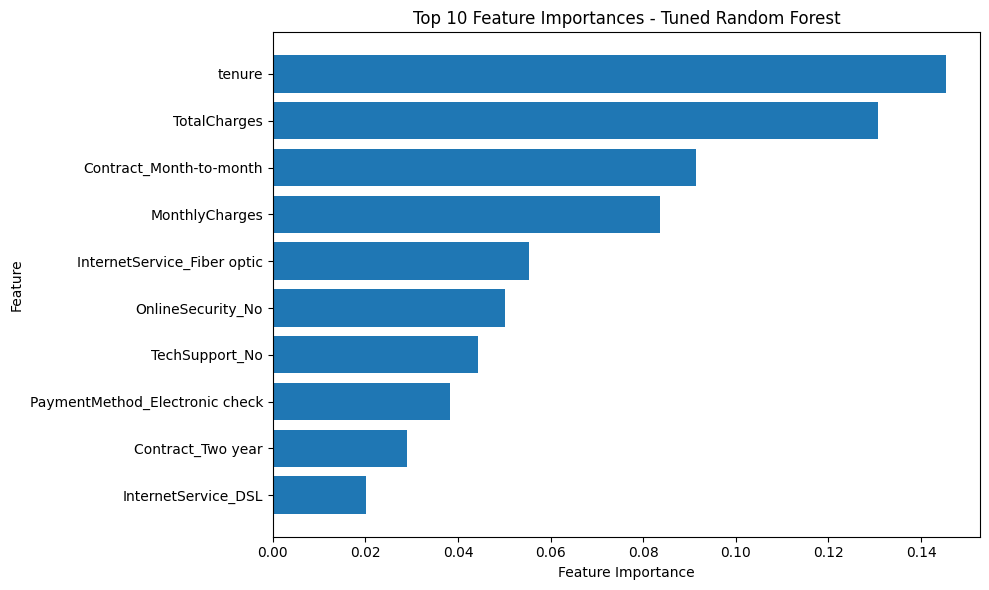

In [41]:
import matplotlib.pyplot as plt
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tuned_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Tuned Random Forest")

plt.tight_layout()
plt.show()

# Task 15 interpretation
The Tuned Random Forest identified tenure, TotalCharges, Contract_Month-to-month, MonthlyCharges, and InternetService_Fiber optic as the five most important features. These results are partly consistent with the Decision Tree from Lab 3, which also identified contract type, internet service, and tenure among its most important features. However, the Random Forest distributed importance more broadly across several features, whereas the Decision Tree placed much greater importance on Contract_Month-to-month. This difference is expected because the two models learn decision patterns differently. Feature importance indicates how much the model relies on a feature and should not be interpreted as evidence of causation.

# Part 7: Kaggle Submission & Conclusion

# Task 16

In [42]:
raw_df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

raw_df["TotalCharges"] = pd.to_numeric(
    raw_df["TotalCharges"],
    errors="coerce"
).fillna(0)

duplicate_mask = raw_df.drop(columns=["customerID"]).duplicated()
raw_df = raw_df.loc[~duplicate_mask].reset_index(drop=True)

customer_ids = raw_df["customerID"]


X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X,
    y,
    customer_ids,
    test_size=0.20,
    random_state=42,
    stratify=y
)

final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

submission = pd.DataFrame({
    "customerID": id_test,
    "Churn": final_predictions
})

submission["Churn"] = submission["Churn"].map({
    0: "No",
    1: "Yes"
})


print("Submission shape:", submission.shape)
display(submission.head())

submission.to_csv("submission.csv", index=False)

print("submission.csv saved successfully.")

Submission shape: (1405, 2)


,customerID,Churn
5615,9334-GWGOW,Yes
6112,9190-MFJLN,No
2356,5103-MHMHY,Yes
2196,7951-VRDVK,No
832,3487-EARAT,No


submission.csv saved successfully.


# Task 16 interpretation
The final Tuned Random Forest was used to generate churn predictions for the 1,405 customers in the held-out test set. A submission dataframe containing the original customer IDs and predicted Churn labels was created. The predictions were converted from numeric values to the original Yes and No labels. The resulting dataframe was saved as submission.csv for submission-style use.

# Task 17
In this lab, a Decision Tree and Random Forest models were trained and compared for customer churn prediction. The default Random Forest performed worse than the Decision Tree, while hyperparameter tuning improved the Random Forest substantially. The Tuned Random Forest achieved the best cross-validation F1-score of 0.5778 and the highest test accuracy and precision, although the Decision Tree achieved a higher test F1-score of 0.5969 and recall of 0.5753. Feature importance analysis showed that tenure, TotalCharges, contract type, MonthlyCharges, and InternetService_Fiber optic were among the most important features for the Tuned Random Forest. Based on the combined cross-validation and test-set evidence, the Tuned Random Forest was selected as the final model.

# Task 18
Future work could include testing additional machine learning algorithms. Class imbalance could also be addressed using techniques such as class weighting or resampling methods to improve churn recall.Additional customer behavior and service-related features could also be engineered to provide the models with more useful information for churn prediction. Finally, the selected model could be deployed as a practical churn prediction system that allows businesses to identify customers at higher risk of leaving.